# Supervision phase diagram

Map the regimes in which fixed-pi self-training improves upon the matched supervised baseline as supervision and noise vary.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    trajectory_diagnostics,
    plot_macroscopic_evolution,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler


The comparison is paired: for each $(\rho,\sigma)$, the supervised and self-training runs use the same finite-design seed and the same state-evolution base streams.  Consequently, their difference isolates the pseudo-labelled contribution rather than a change in the environment.

In [3]:
SEED = 4100
T, D, DELTA, P = 50, 1000, 2.0, 0.2
K_W, K_G = 3_000, 3_800
RHOS = np.array([0.002, 0.005, 0.01, 0.02, 0.05, 0.1])
SIGMAS = np.linspace(0.1, 1.0, 7)

self_error = np.empty((len(SIGMAS), len(RHOS)))
sup_error = np.empty_like(self_error)
for i, sigma in enumerate(SIGMAS):
    for j, rho in enumerate(RHOS):
        common = dict(d=D, delta=DELTA, n_test=2_000, label_prior=P, rho=float(rho), sigma=float(sigma), signal_std=1.0, K_w=K_W, K_g=K_G)
        cfg_st = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=logit(0.8))
        cfg_sup = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=0.0, kappa=logit(0.8))
        pair_seed = SEED + 100 * i + j
        st = run_experiment(name="self-training", algo_cfg=cfg_st, seed=pair_seed, **common)
        sup = run_experiment(name="supervised", algo_cfg=cfg_sup, seed=pair_seed, **common)
        self_error[i, j] = state_evolution_state_observables(st)["error"][-1]
        sup_error[i, j] = state_evolution_state_observables(sup)["error"][-1]

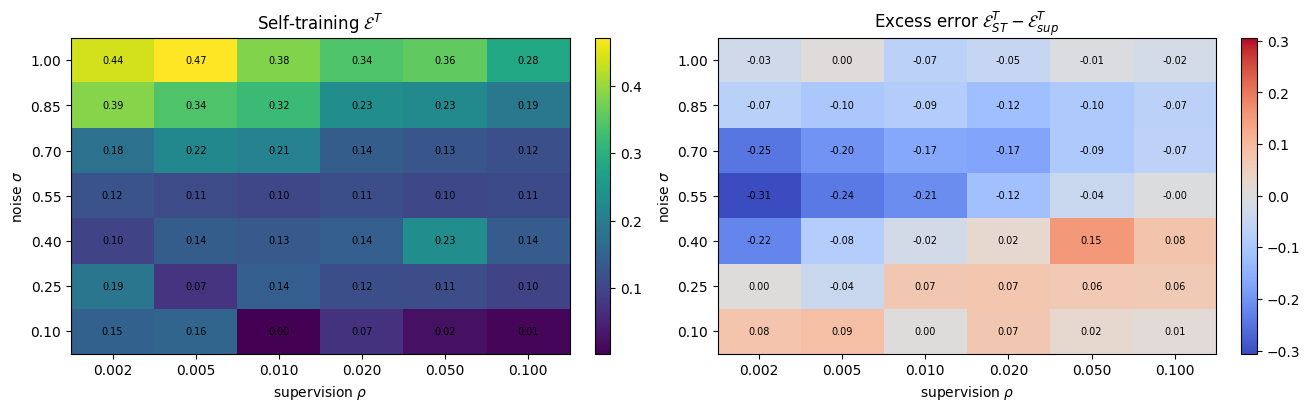

In [4]:
rounded_rhos = [f"{r:.3f}" for r in RHOS]
rounded_sigmas = [f"{s:.2f}" for s in SIGMAS]

excess_error = self_error - sup_error
color_limit = np.max(np.abs(excess_error))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, matrix, title, cmap in (
    (axes[0], self_error, r"Self-training $\mathcal{E}^T$", "viridis"),
    (axes[1], excess_error, r"Excess error $\mathcal{E}_{ST}^T-\mathcal{E}_{sup}^T$", "coolwarm"),
):
    image = ax.imshow(
        matrix, aspect="auto", origin="lower", cmap=cmap,
        vmin=-color_limit if cmap == "coolwarm" else None,
        vmax=color_limit if cmap == "coolwarm" else None,
    )
    ax.set(
        xticks=np.arange(len(RHOS)), xticklabels=rounded_rhos, 
        yticks=np.arange(len(SIGMAS)), yticklabels=rounded_sigmas, 
        xlabel=r"supervision $\rho$", ylabel=r"noise $\sigma$", 
        title=title
    )
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(image, ax=ax)

plt.show()

## Comparison: Labeled-Unlabeled-Oracle-Bayes ($\rho = 0.002, \sigma = 0.55$)

In [5]:
# Matched-data trajectory comparison
#
# The oracle uses the same total sample size n as the self-training arm, with
# every observation revealed as labelled (rho=1).  Thus it is a labelled-data
# upper benchmark, not the selected-label counterfactual used elsewhere.
COMPARISON_DELTA, COMPARISON_P, COMPARISON_T = DELTA, P, 400
COMPARISON_RHO, COMPARISON_SIGMA = 0.002, 0.55
comparison_common = dict(
    d=D, delta=COMPARISON_DELTA, n_test=2_000, label_prior=P,
    sigma=COMPARISON_SIGMA, signal_std=1.0, K_w=K_W, K_g=K_G,
)
comparison_cfg = dict(T=COMPARISON_T, eta=0.8, penalty=0.1, kappa=logit(0.8))
comparison_seed = SEED + 10_000
comparison_runs = {
    "labelled only ($\pi=0$)": run_experiment(
        name="labelled only", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "unlabelled ($\pi=2$)": run_experiment(
        name="unlabelled", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=2.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "oracle (all $n$ labelled)": run_experiment(
        name="oracle", rho=1.0,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
}

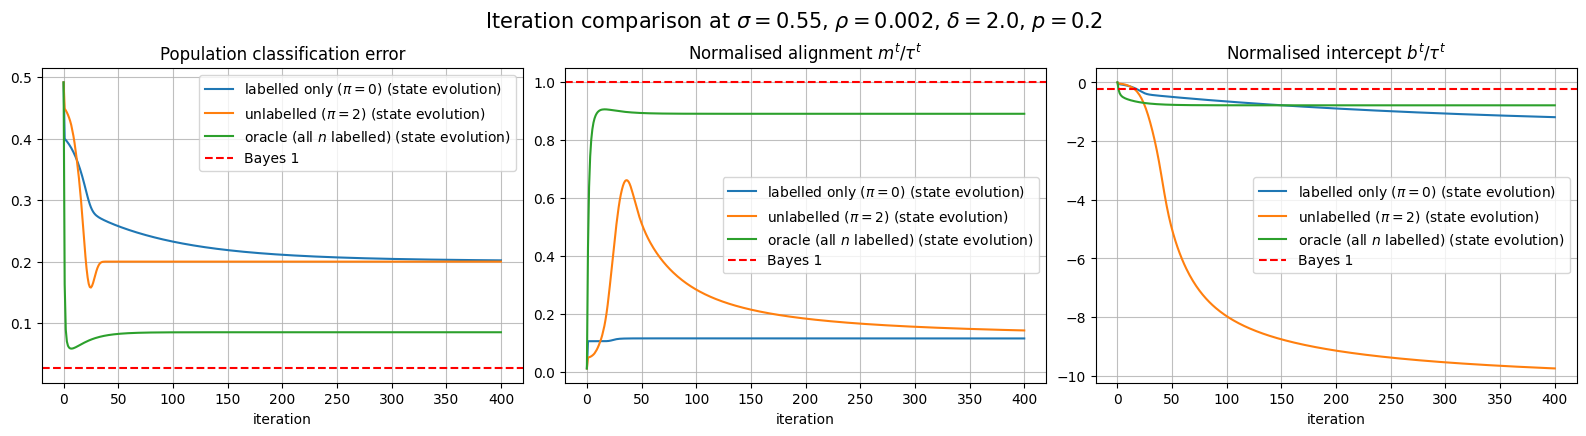

(<Figure size 1575x425 with 3 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [6]:
plot_macroscopic_evolution(
    comparison_runs,
    quantities=("error", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=True,
    title=(
        rf"Iteration comparison at $\sigma={COMPARISON_SIGMA}$, $\rho={COMPARISON_RHO}$, "
        rf"$\delta={COMPARISON_DELTA}$, $p={COMPARISON_P}$"
    ),
)

## Comparison: Labeled-Unlabeled-Oracle-Bayes ($\rho = 0.05, \sigma = 0.4$)

In [7]:
# Matched-data trajectory comparison
#
# The oracle uses the same total sample size n as the self-training arm, with
# every observation revealed as labelled (rho=1).  Thus it is a labelled-data
# upper benchmark, not the selected-label counterfactual used elsewhere.
COMPARISON_DELTA, COMPARISON_P, COMPARISON_T = DELTA, P, 400
COMPARISON_RHO, COMPARISON_SIGMA = 0.05, 0.4
comparison_common = dict(
    d=D, delta=COMPARISON_DELTA, n_test=2_000, label_prior=P,
    sigma=COMPARISON_SIGMA, signal_std=1.0, K_w=K_W, K_g=K_G,
)
comparison_cfg = dict(T=COMPARISON_T, eta=0.8, penalty=0.1, kappa=logit(0.8))
comparison_seed = SEED + 10_000
comparison_runs = {
    "labelled only ($\pi=0$)": run_experiment(
        name="labelled only", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "unlabelled ($\pi=2$)": run_experiment(
        name="unlabelled", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=2.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "oracle (all $n$ labelled)": run_experiment(
        name="oracle", rho=1.0,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
}

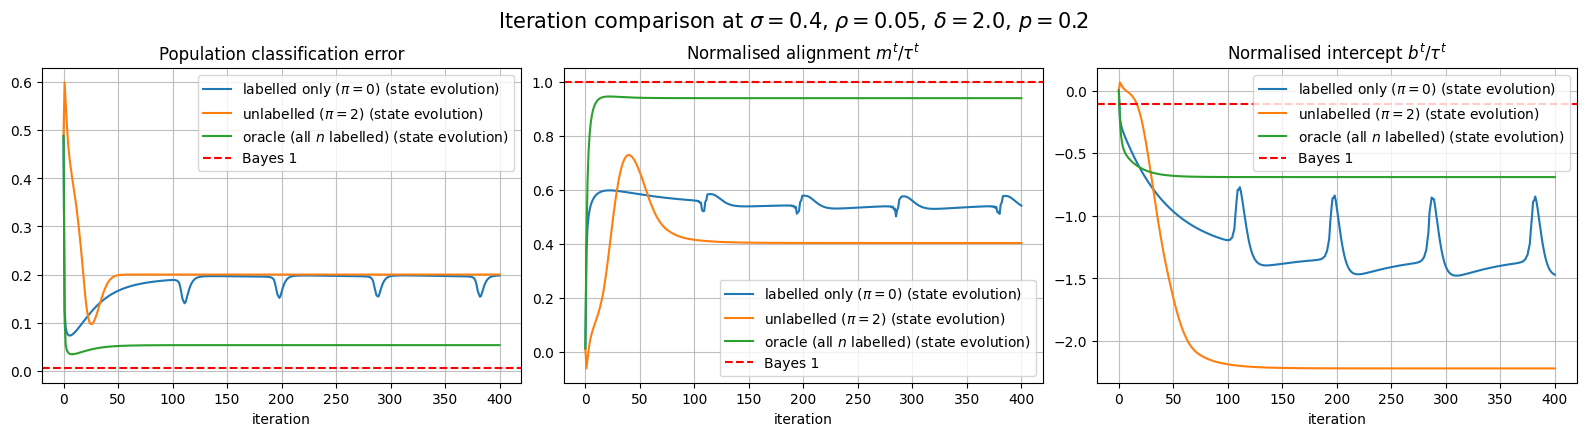

(<Figure size 1575x425 with 3 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [8]:
plot_macroscopic_evolution(
    comparison_runs,
    quantities=("error", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=True,
    title=(
        rf"Iteration comparison at $\sigma={COMPARISON_SIGMA}$, $\rho={COMPARISON_RHO}$, "
        rf"$\delta={COMPARISON_DELTA}$, $p={COMPARISON_P}$"
    ),
)

## Uncertainty-aware phase maps

The terminal map is an excess-error map, where negative entries mean that self-training improves on supervised learning. 

The optional repeated computation below estimates terminal and best-over-time excess error and a numerical collapse frequency.

In [18]:
RUN_REPEATED_PHASE_DIAGRAM = True
PHASE_REPETITIONS = 5
if RUN_REPEATED_PHASE_DIAGRAM:
    terminal_excess = np.empty((len(SIGMAS), len(RHOS)))
    best_excess = np.empty_like(terminal_excess)
    collapse_probability = np.empty_like(terminal_excess)
    for i, sigma in enumerate(SIGMAS):
        for j, rho in enumerate(RHOS):
            outcomes = []
            for repetition in range(PHASE_REPETITIONS):
                common = dict(d=D, delta=DELTA, n_test=2_000, label_prior=0.2, rho=float(rho), sigma=float(sigma), signal_std=1.0, K_w=K_W, K_g=K_G)
                seed = SEED + 1_000_000 * i + 10_000 * j + repetition
                try:
                    st = run_experiment(name="ST", algo_cfg=make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=logit(0.8)), seed=seed, **common)
                    sup = run_experiment(name="SUP", algo_cfg=make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=0.0, kappa=logit(0.8)), seed=seed, **common)
                    outcomes.append((trajectory_diagnostics(st), trajectory_diagnostics(sup)))
                except ValueError:
                    print("[ValueError: finite self-training requires at least one labelled observation]")
                    print("Possibly due to no labeled data at initialization, skipped.")
                    print(f"(i, sigma) = {(i, float(sigma))}, (j, rho) = {(j, float(rho))}, repetition = {repetition}")
                    continue
            terminal_excess[i, j] = np.mean([st["terminal_error"] - sup["terminal_error"] for st, sup in outcomes])
            best_excess[i, j] = np.mean([st["minimum_error"] - sup["minimum_error"] for st, sup in outcomes])
            collapse_probability[i, j] = np.mean([st["collapsed"] for st, _ in outcomes])
    bound = max(np.abs(terminal_excess).max(), np.abs(best_excess).max())

[ValueError: finite self-training requires at least one labelled observation]
Possibly due to no labeled data at initialization, skipped.
(i, sigma) = (2, 0.4), (j, rho) = (0, 0.002), repetition = 2
[ValueError: finite self-training requires at least one labelled observation]
Possibly due to no labeled data at initialization, skipped.
(i, sigma) = (4, 0.7), (j, rho) = (0, 0.002), repetition = 4


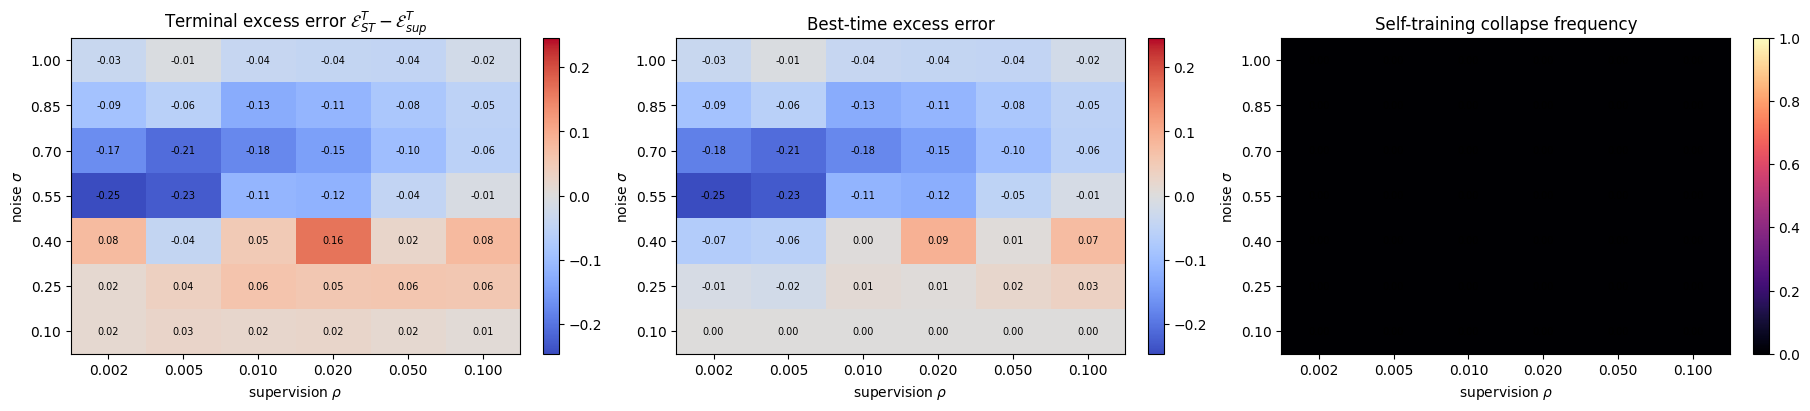

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
for ax, values, title, cmap, norm in (
    (axes[0], terminal_excess, r"Terminal excess error $\mathcal{E}_{ST}^T-\mathcal{E}_{sup}^T$", "coolwarm", plt.Normalize(-bound, bound)),
    (axes[1], best_excess, r"Best-time excess error", "coolwarm", plt.Normalize(-bound, bound)),
    (axes[2], collapse_probability, "Self-training collapse frequency", "magma", plt.Normalize(0, 1)),
):
    image=ax.imshow(values, origin="lower", aspect="auto", cmap=cmap, norm=norm)
    ax.set(xticks=np.arange(len(RHOS)), xticklabels=[f"{x:.3f}" for x in RHOS], yticks=np.arange(len(SIGMAS)), yticklabels=[f"{x:.2f}" for x in SIGMAS], xlabel=r"supervision $\rho$", ylabel=r"noise $\sigma$", title=title)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]): ax.text(column, row, f"{values[row, column]:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(image, ax=ax)
plt.show()